#Proyecto: Conjoint basado en Ratings
###Asignatura: Analítica para la Inteligencia de Negocios

###Librerias

In [ ]:
import pandas as pd
import numpy as np
import statsmodels.api as sm
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder
import warnings
warnings.filterwarnings('ignore')

###Exploracion y limpieza de datos

In [ ]:

#cargar datos
df = pd.read_csv('/content/Formulario_respuestas.csv')

# Ver las primeras filas
df.head()

,Marca temporal,Paquete 1\nContenido: 3 Tacos de Pastor\nBebida: 1 Agua fresca (355 ml)\nTiempo de entrega: 10 min\nPrecio: $75,Paquete 2\n3 Tacos de Pastor + 1 Refresco\n20 min\n$95,Paquete 3\n\n3 Tacos de Pastor + Sin bebida\n35 min\n$115,Paquete 4\n3 Tacos de Arrachera + 1 Refresco\n10 min\n$115,Paquete 5\n\n3 Tacos de Arrachera + Sin bebida\n20 min\n$75,Paquete 6\n\n3 Tacos de Arrachera + 1 Agua fresca\n35 min\n$95,Paquete 7\n\n3 Tacos Vegetarianos + Sin bebida 10 min \n$95,Paquete 8\n\n\n3 Tacos Vegetarianos + 1 Agua fresca\n20 min\n$115,Paquete 9\n\n\n\n3 Tacos Vegetarianos + 1 Refresco\n35 min\n$75,Paquete 10\n\n3 Tacos de Pastor + 1 Refresco\n10 min\n$95,Paquete 11\n\n\n3 Tacos de Arrachera + Sin bebida\n20 min\n$115,Paquete 12\n\n3 Tacos Vegetarianos + 1 Agua fresca\n35 min\n$75
0,26/2/2026 13:11:52,7,5,1,5,1,5,1,2,3,2.0,2,4
1,26/2/2026 13:12:37,7,5,2,5,3,3,3,3,3,3.0,1,2
2,26/2/2026 13:19:46,7,8,6,8,5,8,5,8,6,5.0,8,8
3,26/2/2026 13:27:31,9,4,1,3,5,5,5,3,3,7.0,5,8
4,26/2/2026 14:28:22,9,8,1,7,8,9,1,1,1,9.0,6,1


###Diseño de los perfiles

In [ ]:
# 2. DEFINICIÓN DEL DISEÑO (Perfiles del Anexo)
# Mapeamos cada columna de la encuesta a sus atributos reales
profiles = {
    'Paquete 1':  {'Tipo': 'Pastor',      'Tiempo': '10 min', 'Bebida': 'Agua fresca',       'Precio': 75},
    'Paquete 2':  {'Tipo': 'Pastor',      'Tiempo': '20 min', 'Bebida': 'Refresco',   'Precio': 95},
    'Paquete 3':  {'Tipo': 'Pastor',      'Tiempo': '35 min', 'Bebida': 'Sin bebida', 'Precio': 115},
    'Paquete 4':  {'Tipo': 'Arrachera',   'Tiempo': '10 min', 'Bebida': 'Refresco',   'Precio': 115},
    'Paquete 5':  {'Tipo': 'Arrachera',   'Tiempo': '20 min', 'Bebida': 'Sin bebida', 'Precio': 75},
    'Paquete 6':  {'Tipo': 'Arrachera',   'Tiempo': '35 min', 'Bebida': 'Agua fresca',       'Precio': 95},
    'Paquete 7':  {'Tipo': 'Vegetariano', 'Tiempo': '10 min', 'Bebida': 'Sin bebida', 'Precio': 95},
    'Paquete 8':  {'Tipo': 'Vegetariano', 'Tiempo': '20 min', 'Bebida': 'Agua fresca',       'Precio': 115},
    'Paquete 9':  {'Tipo': 'Vegetariano', 'Tiempo': '35 min', 'Bebida': 'Refresco',   'Precio': 75},
    'Paquete 10': {'Tipo': 'Pastor',      'Tiempo': '10 min', 'Bebida': 'Refresco',   'Precio': 95},
    'Paquete 11': {'Tipo': 'Arrachera',   'Tiempo': '20 min', 'Bebida': 'Sin bebida', 'Precio': 115},
    'Paquete 12': {'Tipo': 'Vegetariano', 'Tiempo': '35 min', 'Bebida': 'Agua fresca',       'Precio': 75},
}

Se cambian los nombres de las columnas par aun manejo más sencillo

In [ ]:
df = df.drop('Marca temporal', axis=1)

In [ ]:
new_column_names = [f'Paquete {i}' for i in range(1, 13)]
df.columns = new_column_names
display(df.head())

,Paquete 1,Paquete 2,Paquete 3,Paquete 4,Paquete 5,Paquete 6,Paquete 7,Paquete 8,Paquete 9,Paquete 10,Paquete 11,Paquete 12
0,7,5,1,5,1,5,1,2,3,2.0,2,4
1,7,5,2,5,3,3,3,3,3,3.0,1,2
2,7,8,6,8,5,8,5,8,6,5.0,8,8
3,9,4,1,3,5,5,5,3,3,7.0,5,8
4,9,8,1,7,8,9,1,1,1,9.0,6,1


In [ ]:
print(f"\nDimensiones: {df.shape}")
print(f"Número de encuestados: {df.shape[0]}")
print(f"Número de paquetes: {df.shape[1]}")


Dimensiones: (31, 12)
Número de encuestados: 31
Número de paquetes: 12


##Formato Largo

Formato Largo (long format) se refiere a la estructura de la tabla de datos donde cada fila representa una única observación o evaluación, en lugar de tener todas las respuestas de un encuestado en una sola fila.

In [ ]:
df['RespondentID'] = range(len(df))
df_long = df.melt(id_vars=['RespondentID'],
                      value_vars=[f'Paquete {i}' for i in range(1, 13)],
                      var_name='Paquete', value_name='Rating')

In [ ]:
# Mapear atributos a cada fila
df_long['Tipo']   = df_long['Paquete'].apply(lambda x: profiles[x]['Tipo'])
df_long['Tiempo'] = df_long['Paquete'].apply(lambda x: profiles[x]['Tiempo'])
df_long['Bebida'] = df_long['Paquete'].apply(lambda x: profiles[x]['Bebida'])
df_long['Precio'] = df_long['Paquete'].apply(lambda x: profiles[x]['Precio']).astype(str) # Categórica

In [ ]:
df_long.to_csv('df_long.csv', index=False)

###Datos Nulos

In [ ]:
# Eliminar nulos si existen
df_long = df_long.dropna(subset=['Rating'])

In [ ]:
df_long.head()

,RespondentID,Paquete,Rating,Tipo,Tiempo,Bebida,Precio
0,0,Paquete 1,7.0,Pastor,10 min,Agua fresca,75
1,1,Paquete 1,7.0,Pastor,10 min,Agua fresca,75
2,2,Paquete 1,7.0,Pastor,10 min,Agua fresca,75
3,3,Paquete 1,9.0,Pastor,10 min,Agua fresca,75
4,4,Paquete 1,9.0,Pastor,10 min,Agua fresca,75


In [ ]:
package_stats = df_long.groupby('Paquete')['Rating'].agg(['mean', 'std', 'count']).round(2)
print("\nEstadísticas por paquete:")
print(package_stats.sort_values('mean', ascending=False))


Estadísticas por paquete:
            mean   std  count
Paquete                      
Paquete 1   8.29  1.79     31
Paquete 10  7.03  2.24     30
Paquete 4   7.00  2.11     31
Paquete 6   6.87  2.86     31
Paquete 5   6.61  2.58     31
Paquete 2   6.42  1.96     31
Paquete 12  6.23  2.87     31
Paquete 9   5.81  2.98     31
Paquete 11  5.48  2.39     31
Paquete 8   5.19  2.51     31
Paquete 7   4.71  2.61     31
Paquete 3   3.00  2.46     31


###Modelado
Se usara un modelo de regresion lineal ols con one hot para predecir la relacion de los atributos con el rating

In [ ]:
# Crear variables dummy (one-hot encoding)
df_dummies = pd.get_dummies(df_long[['Precio', 'Bebida', 'Tiempo', 'Tipo']],
                            prefix=['Precio', 'Bebida', 'Tiempo', 'Tipo'],
                            drop_first=False)

In [ ]:
# Añadir la variable dependiente y el intercepto
X = df_dummies
y = df_long['Rating']

In [ ]:
# Añadir constante para el intercepto
X_with_const = sm.add_constant(X)

In [ ]:
# Ajustar el modelo OLS
model = sm.OLS(y.astype(float), X_with_const.astype(float)).fit()

In [ ]:
print("\nResumen del modelo:")
print(model.summary().tables[1])


Resumen del modelo:
                         coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------------
const                  2.5944      0.055     47.236      0.000       2.486       2.702
Precio_115             0.0047      0.194      0.024      0.981      -0.378       0.387
Precio_75              1.7481      0.194      8.994      0.000       1.366       2.130
Precio_95              0.8416      0.195      4.326      0.000       0.459       1.224
Bebida_Agua fresca     1.6299      0.194      8.385      0.000       1.248       2.012
Bebida_Refresco        1.2502      0.195      6.426      0.000       0.868       1.633
Bebida_Sin bebida     -0.2856      0.194     -1.470      0.143      -0.668       0.097
Tiempo_10 min          1.5082      0.195      7.753      0.000       1.126       1.891
Tiempo_20 min          1.0154      0.194      5.224      0.000       0.633       1.398
Tiempo_35 min         

###Utilidades parciales

In [ ]:
utilities = model.params
print("\nUtilidades parciales (coeficientes):")
for attr, value in utilities.items():
    if attr != 'const':
        print(f"{attr}: {value:.4f}")


Utilidades parciales (coeficientes):
Precio_115: 0.0047
Precio_75: 1.7481
Precio_95: 0.8416
Bebida_Agua fresca: 1.6299
Bebida_Refresco: 1.2502
Bebida_Sin bebida: -0.2856
Tiempo_10 min: 1.5082
Tiempo_20 min: 1.0154
Tiempo_35 min: 0.0707
Tipo_Arrachera: 1.7681
Tipo_Pastor: 0.7448
Tipo_Vegetariano: 0.0815


Interpretación de resultados

- El precio mas aceptado es el de 75 pesos
- Las aguas frescas superan la preferencia sobre los refrescos
- La arrachera es el taco preferido
- 10 minutos es el tiempo de espera mejor valorado


In [ ]:
# Organizar utilidades por atributo
attribute_utilities = {}
current_attribute = None
for col in utilities.index:
    if col != 'const':
        attr_parts = col.split('_')
        if len(attr_parts) >= 2:
            attr_name = attr_parts[0]
            if attr_name not in attribute_utilities:
                attribute_utilities[attr_name] = {}
            level = '_'.join(attr_parts[1:])
            attribute_utilities[attr_name][level] = utilities[col]

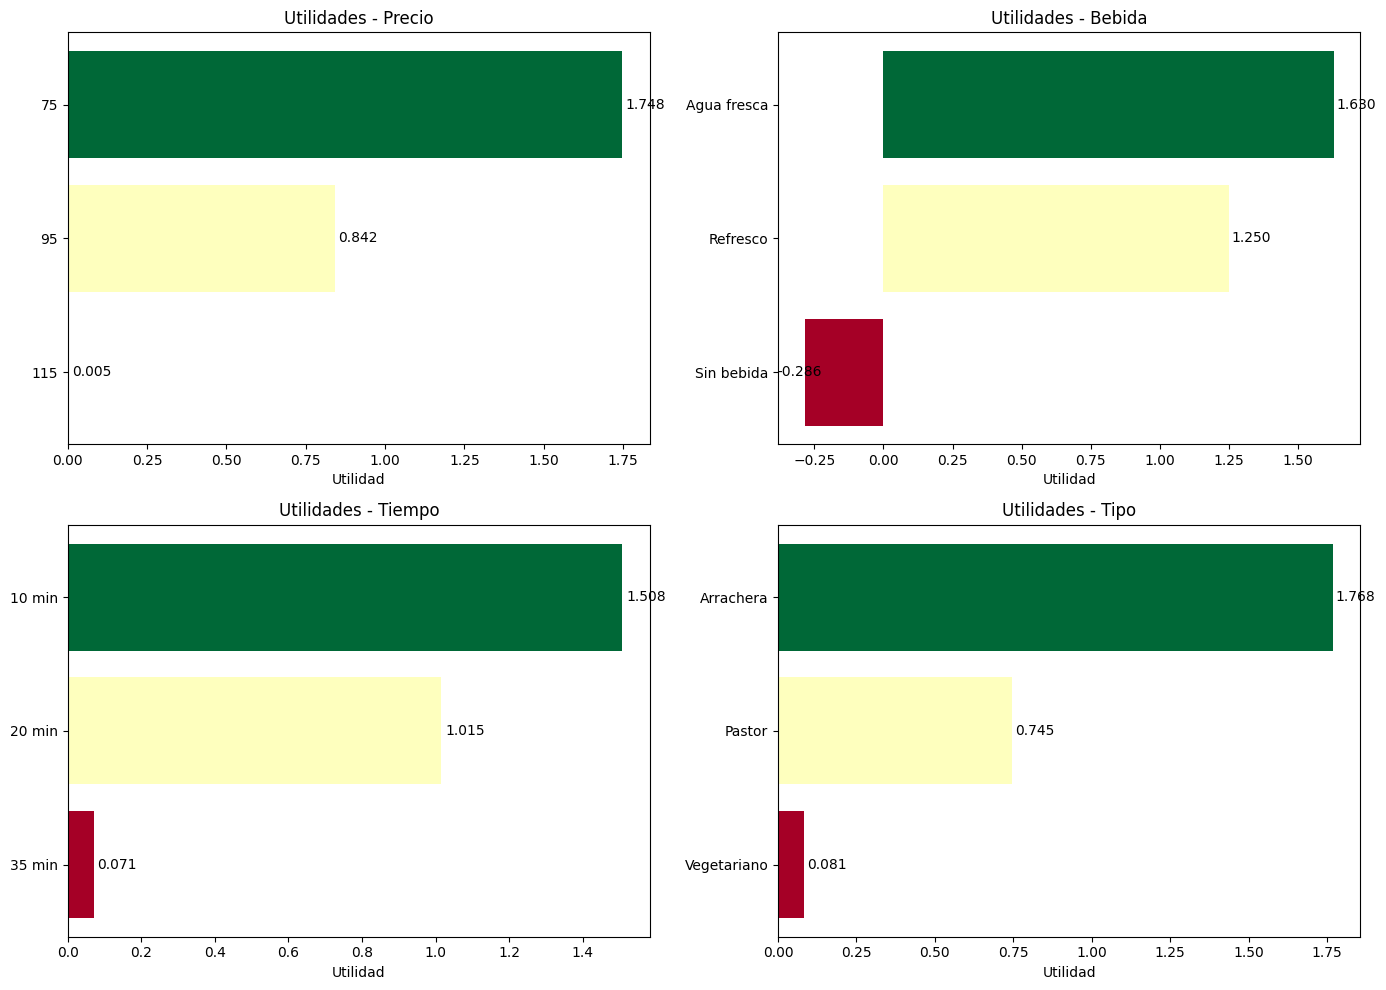

In [ ]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

for i, (attr, levels) in enumerate(attribute_utilities.items()):
    ax = axes[i]
    level_names = list(levels.keys())
    level_values = list(levels.values())

    # Ordenar por valor
    sorted_indices = np.argsort(level_values)
    level_names = [level_names[j] for j in sorted_indices]
    level_values = [level_values[j] for j in sorted_indices]

    colors_levels = plt.cm.RdYlGn(np.linspace(0, 1, len(level_values)))
    bars = ax.barh(level_names, level_values, color=colors_levels)
    ax.set_title(f'Utilidades - {attr.capitalize()}')
    ax.set_xlabel('Utilidad')

    # Añadir valores en las barras
    for j, (bar, val) in enumerate(zip(bars, level_values)):
        ax.text(val + 0.01 if val >= 0 else val - 0.1, bar.get_y() + bar.get_height()/2,
                f'{val:.3f}', va='center')

plt.tight_layout()
plt.savefig('utilidades_parciales.png', dpi=100, bbox_inches='tight')
plt.show()

In [ ]:
# Calcular el rango de utilidades para cada atributo
attribute_ranges = {}
for attr, levels in attribute_utilities.items():
    values = list(levels.values())
    if values:  # Asegurar que no está vacío
        attribute_ranges[attr] = max(values) - min(values)

total_range = sum(attribute_ranges.values())
relative_importance = {attr: (range_val / total_range * 100) for attr, range_val in attribute_ranges.items()}

In [ ]:
print("\nImportancia relativa de cada atributo:")
for attr, imp in sorted(relative_importance.items(), key=lambda x: x[1], reverse=True):
    print(f"{attr.capitalize()}: {imp:.1f}%")


Importancia relativa de cada atributo:
Bebida: 28.2%
Precio: 25.7%
Tipo: 24.9%
Tiempo: 21.2%


#Interpretacion
- Bebida es el atributo más importante (28.2%)

- Le sigue Precio (25.7%)

- Luego Tipo de comida (24.9%)

- Por último Tiempo (21.2%)

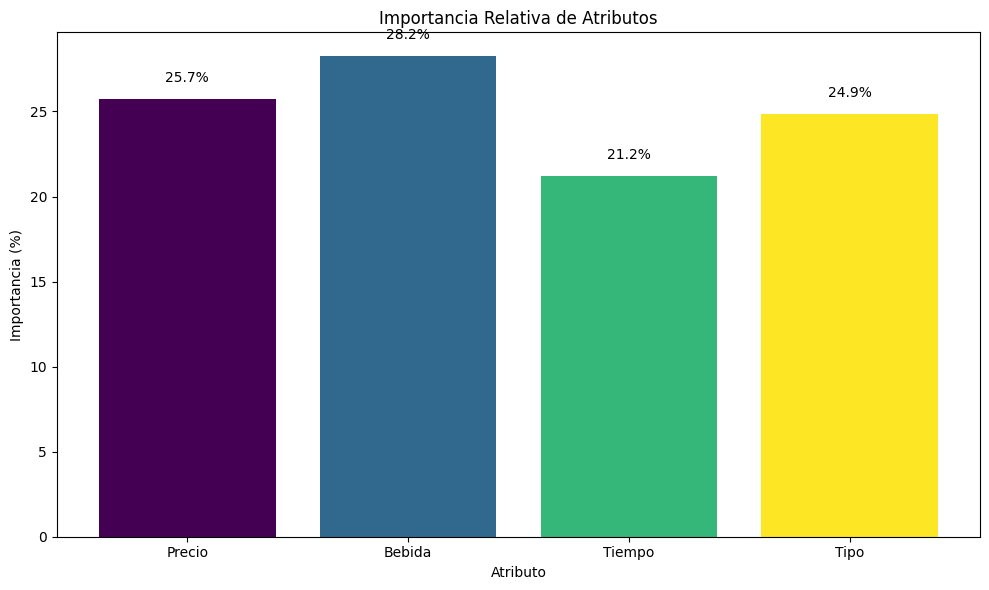

In [ ]:
# Visualización de importancias relativas
plt.figure(figsize=(10, 6))
attrs = list(relative_importance.keys())
imps = list(relative_importance.values())
colors = plt.cm.viridis(np.linspace(0, 1, len(attrs)))

plt.bar(attrs, imps, color=colors)
plt.title('Importancia Relativa de Atributos')
plt.xlabel('Atributo')
plt.ylabel('Importancia (%)')
for i, (attr, imp) in enumerate(zip(attrs, imps)):
    plt.text(i, imp + 1, f'{imp:.1f}%', ha='center')
plt.tight_layout()
plt.savefig('importancia_relativa.png', dpi=100, bbox_inches='tight')
plt.show()

Recomendaciones de negocio basadas en estos datos:
Para el PAQUETE ECONÓMICO:
Precio $75

Bebida: Agua Fresca(es lo más valorado y económico)

Tipo: Pastor (buena relación costo-beneficio)

Tiempo: 20 min (realista para económico)

Para el PAQUETE PREMIUM:
Precio $95 (no conviene $115 porque no aporta)

Bebida: Agua

Tipo: Arrachera

Tiempo: 10 min

Para el PAQUETE ESTÁNDAR:
Precio $75

Bebida: Refresco (segunda opción)

Tipo: Pastor

Tiempo: 20 min

RECOMENDACIÓN: Enfocar esfuerzos en ofrecer AGUA de calidad
y mantener precio competitivo de $75

##Simulacion Escenarios

Se cambia el paquete economico (75) para que sea el vegetariano, el estandard  (95)  pastor y el premium (115) arrachera

In [ ]:
# Definir los tres escenarios
scenarios = {
    'Económico': {
        'Precio': '75',
        'Bebida': 'Agua fresca',
        'Tiempo': '35 min',
        'Tipo': 'Vegetariano'
    },
    'Estándar': {
        'Precio': '95',
        'Bebida': 'Refresco',
        'Tiempo': '20 min',
        'Tipo': 'Pastor'
    },
    'Premium': {
        'Precio': '115',
        'Bebida': 'Agua fresca',
        'Tiempo': '10 min',
        'Tipo': 'Arrachera'
    }
}

In [ ]:
# Función para calcular el score esperado de un paquete
def calculate_expected_score(attributes, utilities, intercept):
    score = intercept
    for attr, level in attributes.items():
        col_name = f"{attr}_{level}"
        if col_name in utilities.index:
            score += utilities[col_name]
        else:
            print(f"Advertencia: {col_name} no encontrado en utilidades")
    return score

# Calcular scores para cada escenario
print("\nScores esperados para cada escenario:")
scenario_scores = {}
for scenario_name, attributes in scenarios.items():
    score = calculate_expected_score(attributes, utilities, utilities['const'])
    scenario_scores[scenario_name] = score
    print(f"{scenario_name}: {score:.2f}")


Scores esperados para cada escenario:
Económico: 6.12
Estándar: 6.45
Premium: 7.51


Se observa una que la preferencia por los tacos de arrachera sigue dominando aunque el precio de este incremente, asi como que lo tacos al pastor se quedan en un punto medio y los vegetarianos al final de las preferencias.

Insight de negocio:

Los clientes están dispuestos a pagar más por arrachera

La elasticidad precio es baja para este producto

Estrategia: Enfocar marketing en la calidad de la arrachera

Recomendaciones de Negocio:

Tacos de arrachera son los favoritos:
- Opcion Premium
- Combos con refresco y agua fresca
- Tiempo de espera de 10-15 minutos

Tacos al pastor opcion estandard
- Opcion Economica
-- Combos con refresco y agua fresca
- Tiempo de espera de 15-20 minutos

Tacos Vegetarianos opcion Saludable:
- Opcion Economica
- Combos con refresco y agua fresca
- Tiempo de espera de 15-20 minutos